# Random Numbers

Random processes, such as radioactive decay and electronic noise, are very common in the physical sciences.
By generating (pseudo) random numbers, we can simulate these phenomenon and attempt to derive (or test) an algorithm description of the underlying process.

This chapter will provide an introduction to generating random numbers and point out some of the practical problems that arise when working with them.
A discussion of the different algorithms that are used to produce random numbers is given in PHYS-P 410.

## Drawing Random Numbers

For this section, we will use the `random` module available in the standard Python library.
The `random()` function generates a random number in the half open interval $[0,1)$, where the upper boundary is excluded.
For example:

In [45]:
import random

print(random.random())

0.2779736031100921


All computations of random numbers are based on deterministic algorithms.
Since the resulting sequence of numbers is not truly random, we refer to them as *pseudo-random number generators*.

More details about the different types of algorithms, along with a discussion about how to choose the right algorithm for a given task, are given in PHYS-P 410.
For now, it is enough to know that the `random` module uses the Mersenne Twister algorithm, which proves a pseudo-random series of numbers with a (huge!) period of $2^{19937}-1$.

### The Seed

Every time we import `random`, the sequence provided by `random.random()` will be different.
However, it's often necessary to get the same sequence of random numbers every time we run the program, either for debugging or reproducibility.
We can achieve this by setting a *seed* before we start generating numbers.

With a given value of the seed, one and only one sequence of numbers is generated.
To set the seed, we pass an integer to the `random.seed()` function:

In [56]:
import random

random.seed(42)
print([random.random() for i in range(5)])

[0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124]


In the above cell, we started by setting the seed to `42`.
Next, we created a list of 5 random numbers using a list comprehension and printed it to the screen.

If we set the seed to `42` again, the same sequence of numbers is generated:

In [57]:
print([random.random() for i in range(5)])

[0.6766994874229113, 0.8921795677048454, 0.08693883262941615, 0.4219218196852704, 0.029797219438070344]


If we do **NOT** give a seed, the `random` module will set a seed based on the current time and date.
That is, the seed will be different each time we run the program, resulting in a different sequence of numbers each time we run the program.
This is often the behavior you want when running a simulation; however, I recommend setting a seed during development to simplify debugging and testing.

### Uniformly Distributed Random Numbers

The numbers generated by `random.random()` will be equally distributed between 0 and 1, which means that there are no parts of the interval $[0,1)$ that are sampled more often than other parts.
We say that the resulting distribution of random numbers in this case is *uniform*.

If we pass two parameters to the function `random.uniform(a,b)`, it will uniformly generate random numbers in the half open interval $[a,b)$.
Let's generate 500 random numbers in the range $[-1,1)$ and visualize how they are distributed:

[0.2788535969157675, -0.9499784895546661, -0.4499413632617615, -0.5535785237023545, 0.4729424283280248, 0.3533989748458226, 0.7843591354096908, -0.8261223347411677, -0.15615636062945915, -0.9404055611238593, -0.5627240503927933, 0.010710576206724776, -0.9469280606322728, -0.602324698626703, 0.2997688755590464, 0.08988296120643335, -0.5591187559186066, 0.17853136775181744, 0.6188609133556533, -0.987002480643878, 0.6116385036656158, 0.3962787899764537, -0.31949896696401625, -0.6890410003764369, 0.9144261444135624, -0.32681090977474647, -0.8145083132397042, -0.806567246333072, 0.6949887326949196, 0.20745206273378214, 0.6142565465487604, 0.45946357338763577, 0.07245618290940148, 0.9462315279587412, -0.24293124558329304, 0.104081262546454, 0.6588093285059897, 0.2370395047284921, 0.7234138006215545, 0.15470429051352408, 0.40914367242984695, -0.9083512326886756, -0.5442034486969063, -0.42122407279578566, -0.840416046152745, -0.5344182272779396, -0.7979971411805418, -0.44405279377981577, 0.271

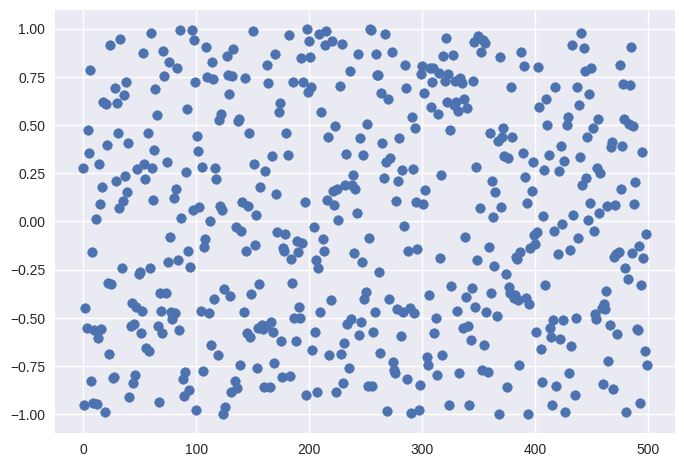

In [64]:
import random
import matplotlib.pyplot as plt

random.seed(42)

# Generate 500 uniformly distributed points between -1 and 1
N = 500
x = range(N)
y = [random.uniform(-1,1) for _ in x]

print(y)

# Plot the results
fig, ax = plt.subplots()
ax.scatter(x,y)

We started by importing the necessary modules, then defined a variable `N` that refers to the value of random numbers we'd like to generate.
Next, we generated an index for each of the `N` points and then used a list comprehension to generate a series of `N` uniform random numbers generated in the interval $[-1,1)$.
Finally, we made a scatter plot of the results, which appear to be random and uniformly distributed between -1 and 1.

### Visualizing the Distribution

When working with random numbers, you will often want to visualize how $N$ random numbers in an interval $[a,b)$ are distributed throughout the interval.
As you increase how many numbers you generate, this will confirm that the distribution is uniform and that you're not messing something up.

We want to do the following:
1. Divide the interval $[a,b)$ into $n$ equally sized sub-intervals, each of length $h=(b-a)/n$. These sub-intervals are called *bins*.
2. Draw $n$ random numbers.
3. Count how many random numbers $H_i$ fall into bin $i$, defined by the sub-interval $[a+ih, a + (i+1)h]$, for $i=0,...,n$.

If $n$ is small, $H_i$ can be quite different for different bins.
However, as $n \rightarrow \infty$, we expect $H_i$ to vary less and less over $i$.

To visualize this, we can use a bar diagram called a *histogram*.
The program below generates uniform random numbers between 0 and 1 then plots them in a histogram, first for $n=10^3$ and then for $n=10^6$.


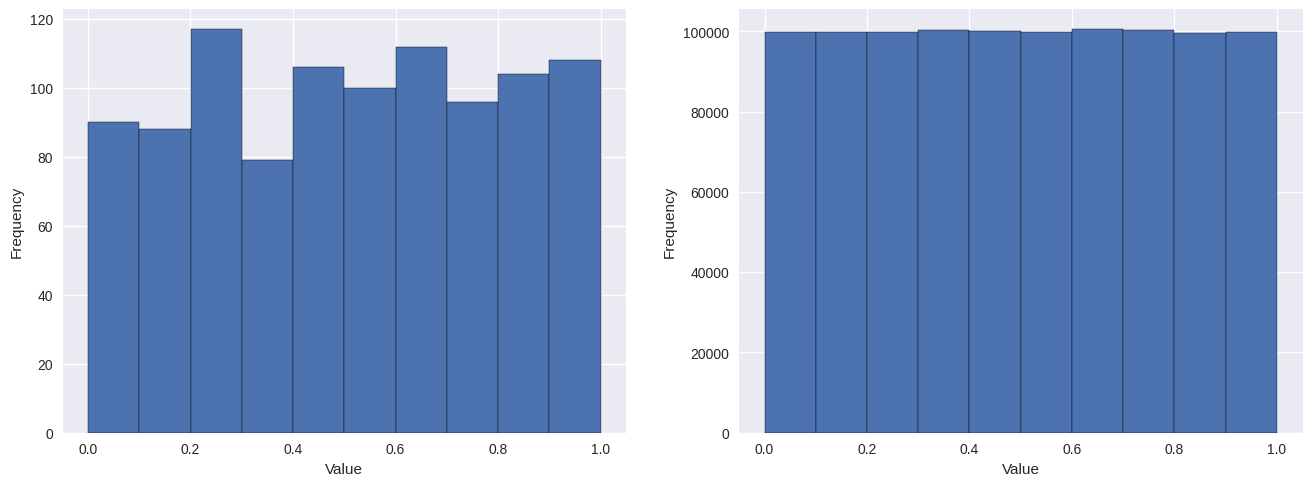

In [66]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)

# Make the figure twice as wide as usual
figure_size = plt.rcParams['figure.figsize'][:]
figure_size[0] *= 2
plt.style.use('seaborn-v0_8')
fig, axs = plt.subplots(1,2, figsize=figure_size)

# Plot a histogram of uniform random numbers between 0 and 1, for two different values of N
N = np.array([1e3, 1e6], dtype=np.int32)
for i in range(len(N)):
    data = [random.random() for _ in range(N[i])]
    axs[i].hist(data, bins=10, ec='black', label=f'N = {N[i]}')
    axs[i].set_xlabel('Value')
    axs[i].set_ylabel('Frequency')
    axs[i].legend


While only sampling one thousand random numbers results in a slightly funny looking histogram, increasing to one million samples shows that the random number generator looks quite uniform.

### Vectorized Drawing of Random Numbers

There is also a `random` module in NumPy, which is much more efficient at drawing a large number of random elements.
You can use it as follows:

In [74]:
import numpy as np

rng = np.random.default_rng(seed = 42)

data = rng.uniform(-1,1,size=int(1e3))
print(data)

[ 0.5479121  -0.12224312  0.71719584  0.39473606 -0.8116453   0.9512447
  0.5222794   0.57212861 -0.74377273 -0.09922812 -0.25840395  0.85352998
  0.28773024  0.64552323 -0.1131716  -0.54552256  0.10916957 -0.87236549
  0.65526234  0.2633288   0.51617548 -0.29094806  0.94139605  0.78624224
  0.55676699 -0.61072258 -0.06655799 -0.91239247 -0.69142102  0.36609791
  0.48952431  0.93501946 -0.34834928 -0.25908059 -0.06088838 -0.62105728
 -0.74015699 -0.04859015 -0.5461813   0.33962799 -0.12569616  0.66535639
  0.4005302  -0.37526672  0.6645196   0.60952871 -0.22504324 -0.42334379
  0.36499101 -0.72049503 -0.6001836  -0.98527546  0.57384876  0.32970171
  0.41033076  0.56145806 -0.08216845  0.13748239 -0.720406   -0.77093985
  0.33680592 -0.05780759  0.13047221  0.52999771  0.26943664  0.1071588
  0.11841432 -0.3920998  -0.93836433 -0.12656522 -0.57083065 -0.18294271
  0.70680615 -0.53212103 -0.88339452 -0.43723222 -0.41281248  0.32383303
  0.1140643   0.56779642  0.32862708 -0.18722628  0.6

The default random number generator used by NumPy is **PCG64**, which has a period of $2^{128}$.

### The Gaussian (Normal) Distribution

Due to the central limit theorem, the Gaussian (or Normal) distribution is one of the most common distributions you'll encounter in the physical sciences.
For example, the statistical distribution of the height or blood pressure among adults of one gender are well described by a Gaussian distribution.

The Gaussian distribution has two parameters: the mean value ($\mu$) and the standard deviation ($\sigma$).
The mean value determines where the distributions peaks, while the standard deviation determines how wide the distribution is.

A few examples are drawn below.

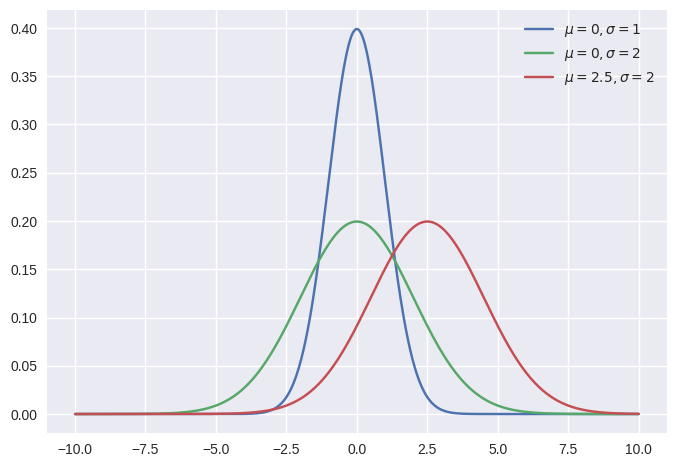

In [87]:
from scipy.stats import norm
import matplotlib.pyplot as plt

x_values = np.linspace(-10,10,1000)

fig, ax = plt.subplots()
ax.plot(x_values, norm.pdf(x_values, loc=0, scale=1), label=r'$\mu=0, \sigma=1$')
ax.plot(x_values, norm.pdf(x_values, loc=0, scale=2), label=r'$\mu=0, \sigma=2$')
ax.plot(x_values, norm.pdf(x_values, loc=2.5, scale=2), label=r'$\mu=2.5, \sigma=2$')
ax.legend()

To generate random numbers from this distribution, you can use either the `random` module from the Python standard library:

In [88]:
import random

# Generate one thousand normal distributed numbers
data = [random.normalvariate(0,1) for _ in range(100)]

For efficiently generating larger datasets, you can use NumPy:

In [89]:
import numpy as np

# Generate one million normal distributed numbers
rng = np.random.default_rng(seed=42)
data = rng.normal(loc=0, scale=1, size=int(1e6))

## Practice

First, use NumPy to uniformly generate 1000 random numbers between 0 and 10 without specifying a seed.
Loop over the dataset and count how many of these numbers are less than 5.
If you run the cell again, do you get the same result?

In [105]:
import numpy as np
rng = np.random.default_rng()
n = 0
data = rng.uniform(0,10,size=int(1e3))
for i in data:
    if i < 5:
        n += 1
    else:
        continue
print(n)

510


Modify your program so that you can reproduce the same result every time. I.e., seed the random number generator with a number of your choosing.

In [109]:
import numpy as np
rng = np.random.default_rng(seed = 42)
n = 0
data = rng.uniform(0,10,size=int(1e3))
for i in data:
    if i < 5:
        n += 1
    else:
        continue
print(n)

503


Next, generate one million Gaussian distributed random numbers and make a histogram of them to confirm that the distribution looks right.
Use a $\mu$ and $\sigma$ of your choice. If you're feeling ambitious, you can fit the distribution with the Gaussian function we worked with last week.

Text(0, 0.5, 'Frequency')

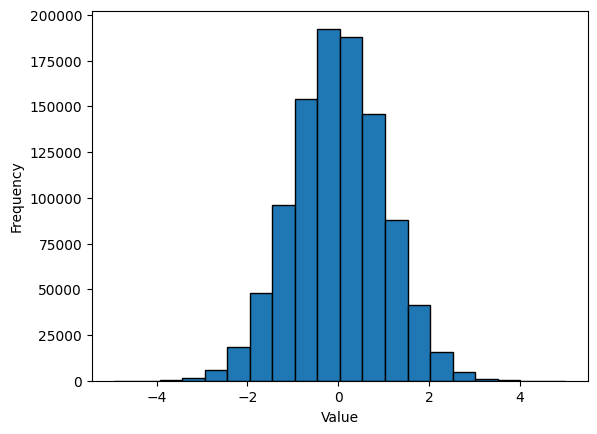

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Generate one million normal distributed numbers
rng = np.random.default_rng(seed = 42)
data = rng.normal(loc=0, scale=1, size=int(1e6))

fig, ax = plt.subplots()
ax.hist(data, bins=20, ec='black')
ax.set_xlabel('Value')
ax.set_ylabel('Frequency')